In [1]:
# Import required libraries
import cv2
import numpy as np
import pandas as pd
from scipy import signal
from datetime import datetime
import os
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def get_face_roi(frame):
    """Extract face region using OpenCV's face detection"""
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    if len(faces) > 0:
        (x, y, w, h) = faces[0]  # Use the first detected face
        return frame[y:y+h, x:x+w]
    return None

def extract_rgb_signals(frame_roi):
    """Extract average RGB values from ROI"""
    # Split ROI into RGB channels and get mean values
    b, g, r = cv2.split(frame_roi)
    return (np.mean(r), np.mean(g), np.mean(b))

In [3]:
def preprocess_rgb_signals(rgb_signals, fps=30):
    """Preprocess RGB signals to get rPPG"""
    # Convert list of tuples to numpy array
    rgb_signals = np.array(rgb_signals)
    
    # Detrend signals
    rgb_detrended = signal.detrend(rgb_signals, axis=0)
    
    # Normalize signals
    rgb_normalized = (rgb_detrended - np.mean(rgb_detrended, axis=0)) / np.std(rgb_detrended, axis=0)
    
    # Apply bandpass filter (0.7-3.5Hz for heart rate range)
    nyquist = fps/2
    low = 0.7/nyquist
    high = 3.5/nyquist
    b, a = signal.butter(3, [low, high], btype='band')
    
    rgb_filtered = signal.filtfilt(b, a, rgb_normalized, axis=0)
    
    # PCA to extract rPPG (using green channel as main component)
    rppg = rgb_filtered[:, 1]  # Green channel
    
    return rppg

In [4]:
def extract_features(rppg_signal, fps=30):
    """Extract features from rPPG signal for BP estimation"""
    # Find peaks (systolic points)
    peaks, _ = signal.find_peaks(rppg_signal, distance=fps//2)
    
    # Calculate peak-to-peak intervals
    pp_intervals = np.diff(peaks) / fps  # in seconds
    
    # Calculate amplitudes
    amplitudes = rppg_signal[peaks]
    
    # Extract features
    features = {
        'mean_interval': np.mean(pp_intervals),
        'std_interval': np.std(pp_intervals),
        'mean_amplitude': np.mean(amplitudes),
        'std_amplitude': np.std(amplitudes),
        'peak_power': np.mean(amplitudes**2)
    }
    
    return features

def estimate_bp(features):
    """
    Estimate blood pressure using rPPG features
    Using simplified linear model based on physiological principles
    """
    # These coefficients are simplified and would need calibration
    # with actual BP measurements for accurate results
    systolic = (
        120 +  # baseline
        (features['mean_amplitude'] * 20) +  # amplitude contribution
        (features['mean_interval'] * -15) +  # interval contribution
        (features['peak_power'] * 10)        # power contribution
    )
    
    diastolic = (
        80 +   # baseline
        (features['mean_amplitude'] * 10) +   # amplitude contribution
        (features['std_interval'] * -5) +     # variability contribution
        (features['peak_power'] * 5)          # power contribution
    )
    
    return systolic, diastolic

In [5]:
def process_video(video_path):
    """Process video to estimate blood pressure"""
    cap = cv2.VideoCapture(video_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    rgb_signals = []
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Get face ROI
        face_roi = get_face_roi(frame)
        if face_roi is not None:
            # Extract RGB signals
            rgb = extract_rgb_signals(face_roi)
            rgb_signals.append(rgb)
    
    cap.release()
    
    # Process signals
    rgb_signals = np.array(rgb_signals)
    rppg = preprocess_rgb_signals(rgb_signals, fps)
    
    # Extract features and estimate BP
    features = extract_features(rppg, fps)
    systolic, diastolic = estimate_bp(features)
    
    return rppg, systolic, diastolic

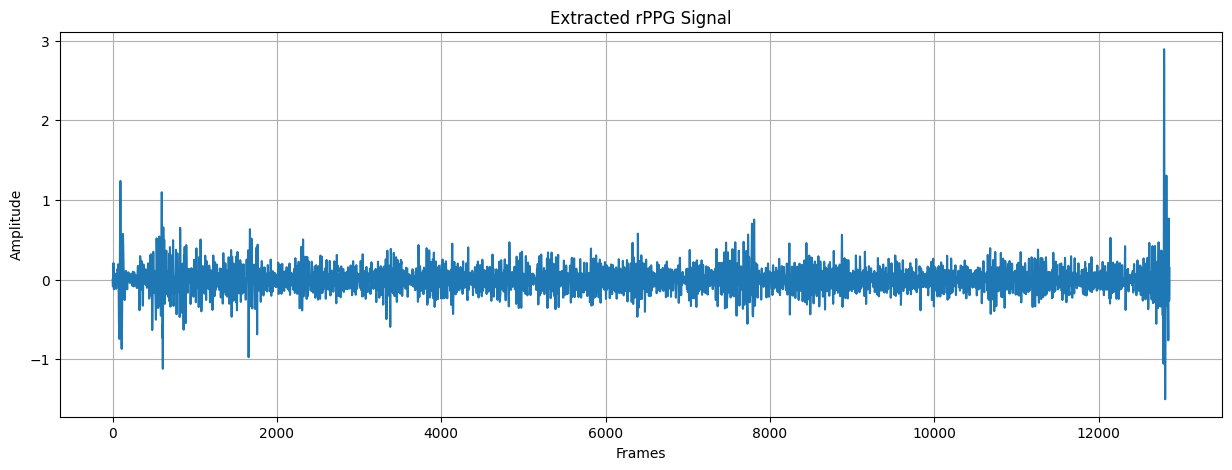

Estimated Blood Pressure:
Systolic: 113.3 mmHg
Diastolic: 81.4 mmHg


In [6]:
# Process video
video_path = "/kaggle/input/rppg-dataset/subject_001/subject_001/trial_001/video/video.MOV"
rppg, systolic, diastolic = process_video(video_path)

# Visualize rPPG signal
plt.figure(figsize=(15, 5))
plt.plot(rppg)
plt.title('Extracted rPPG Signal')
plt.xlabel('Frames')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

print(f"Estimated Blood Pressure:")
print(f"Systolic: {systolic:.1f} mmHg")
print(f"Diastolic: {diastolic:.1f} mmHg")